# Global Petrol Price Analysis

## Summary of Data Visualizations

* **Global Price Distribution**: A histogram showing how petrol prices are distributed worldwide. It reveals a peak between $1.00 and $2.00, with extreme outliers reaching over $4.00.
* **Average Price by Region (Sorted)**: A bar chart ranking regions from most to least expensive. Europe and Oceania lead, while the Middle East has the lowest average prices.
* **Breakdown of Countries by Price Level**: A pie chart illustrating the percentage of countries in categories like "High," "Medium," and "Low."
* **Correlation Matrix of Price Metrics**: A heatmap showing how current prices relate strongly to previous prices, and how price change percentages interact with current valuations.
* **Price Change across Price Levels**: A strip plot that maps the percentage increase or decrease against the country's price level category, segmented by region.
* **Current vs. Previous Price (Top 15 Expensive)**: A side-by-side comparison for the most expensive countries, highlighting where the largest recent jumps occurred.
* **Price Trends Across Regions**: A count plot showing the frequency of trends like "Stable," "Rising," and "Rising Sharply" within each geographical area.
* **Volatility (Price Change %) by Region**: A box plot showing the range of price changes within each region, identifying which areas (like Asia and Oceania) have experienced the most significant price swings.

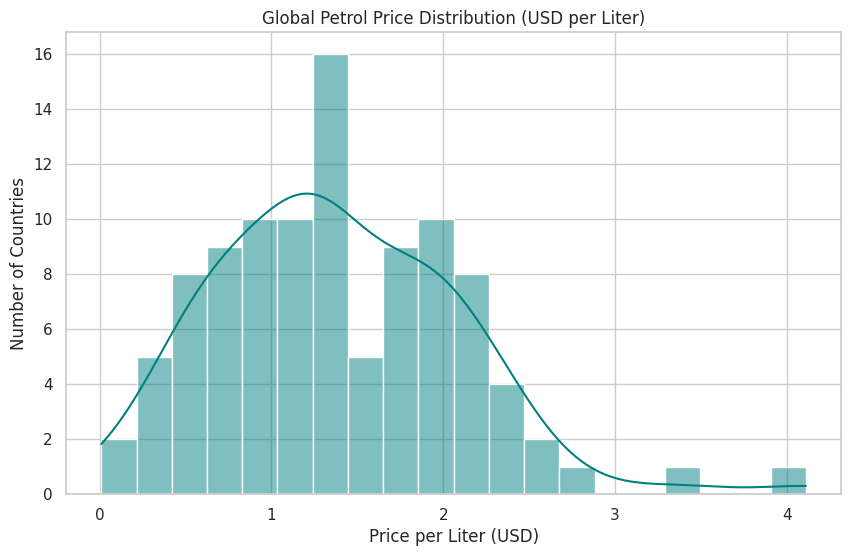

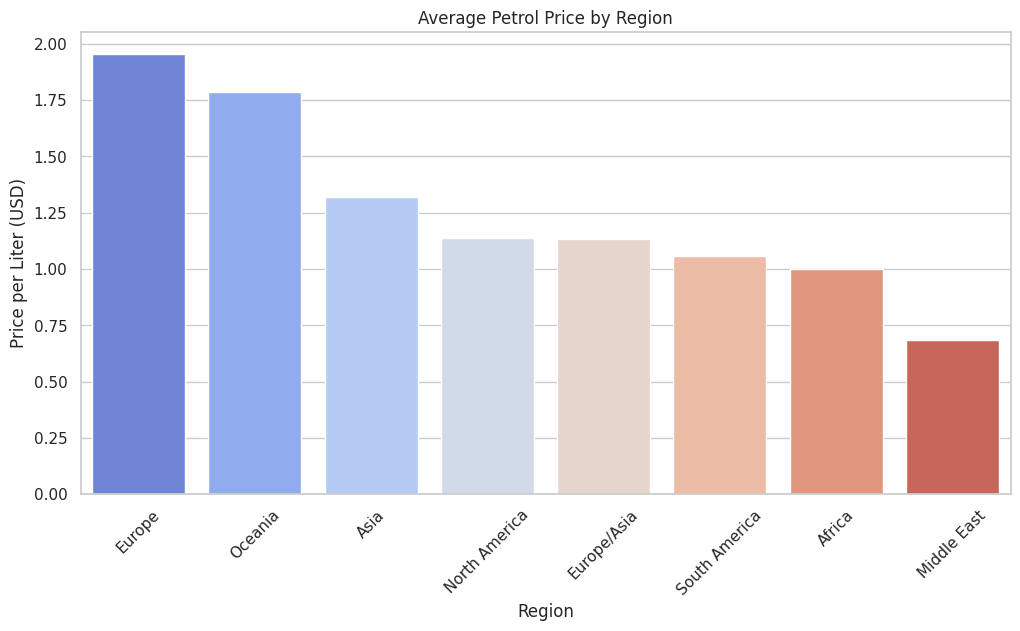

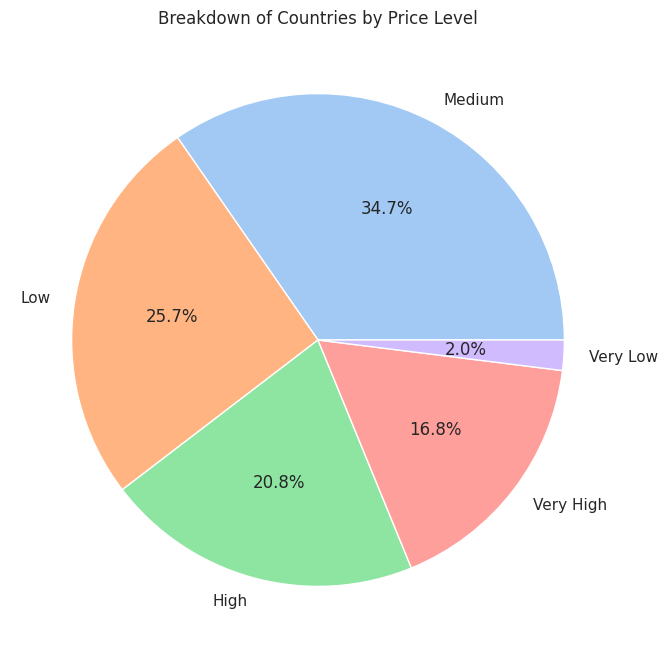

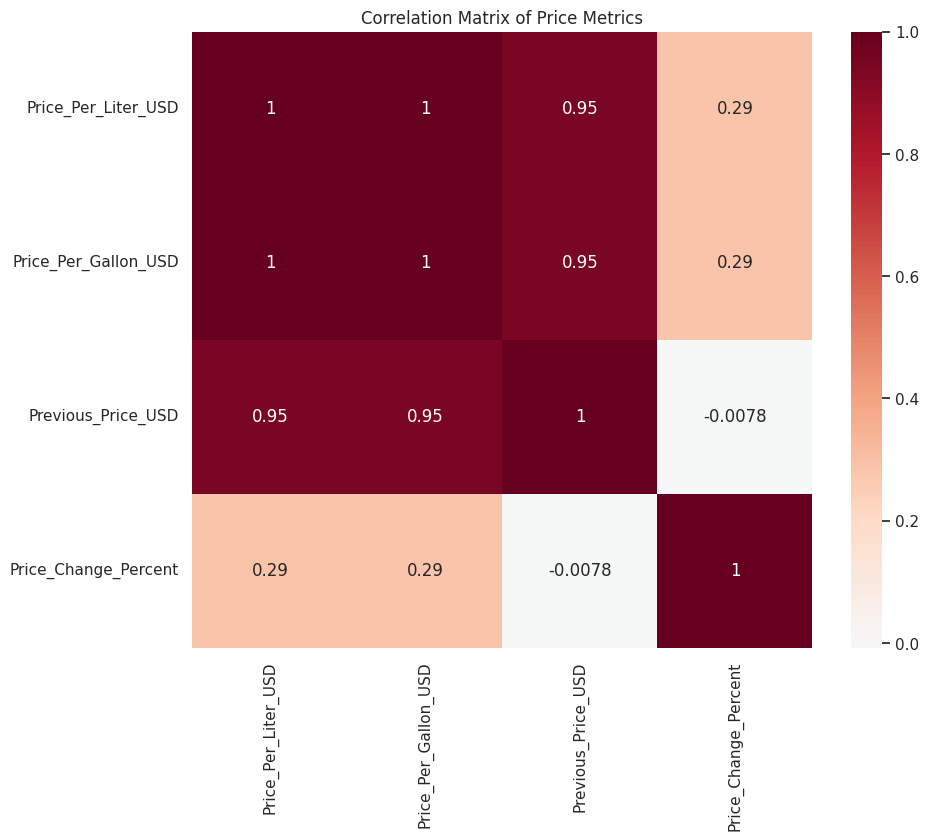

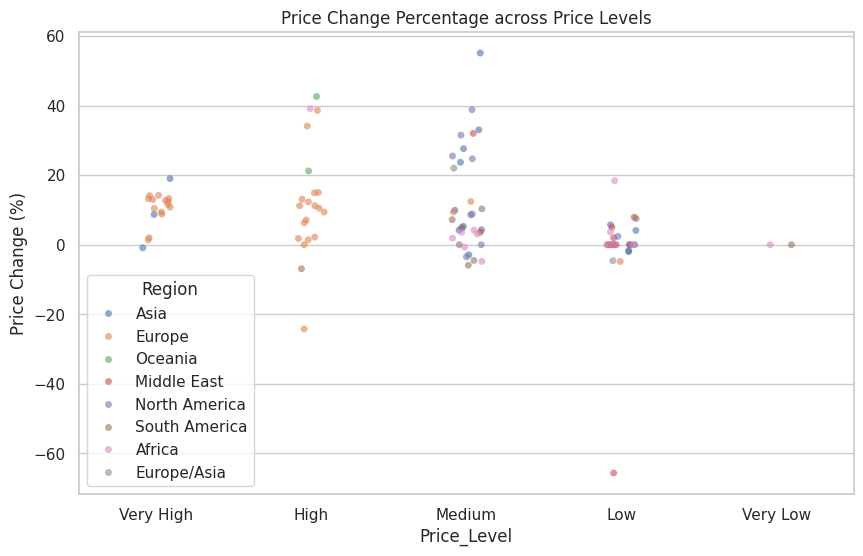

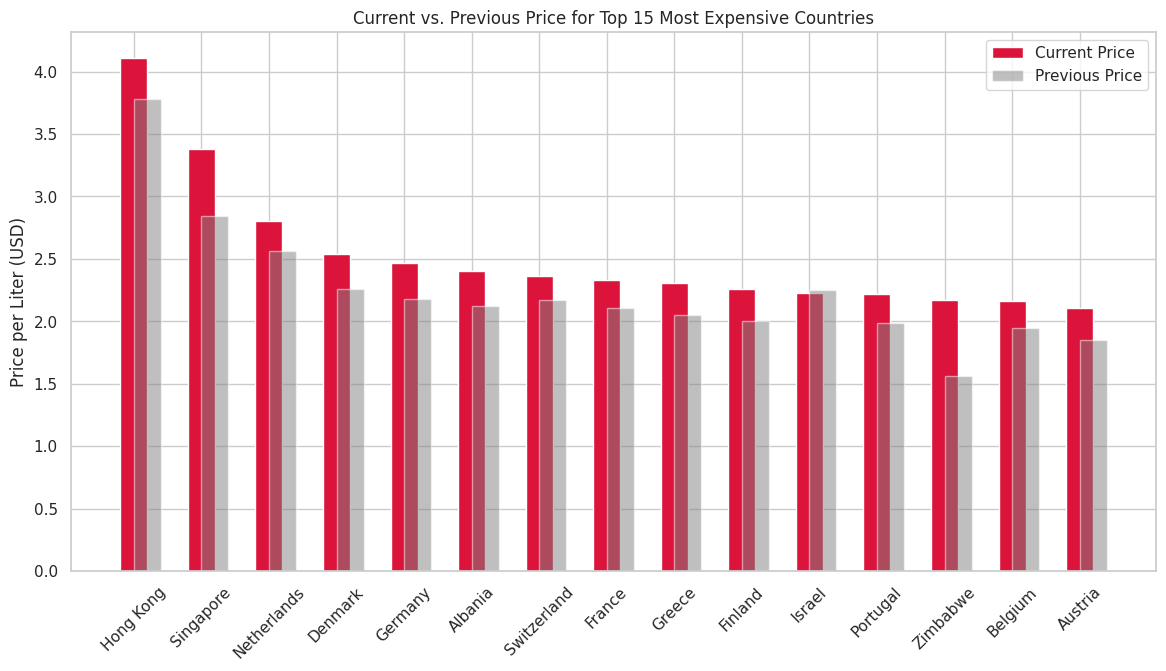

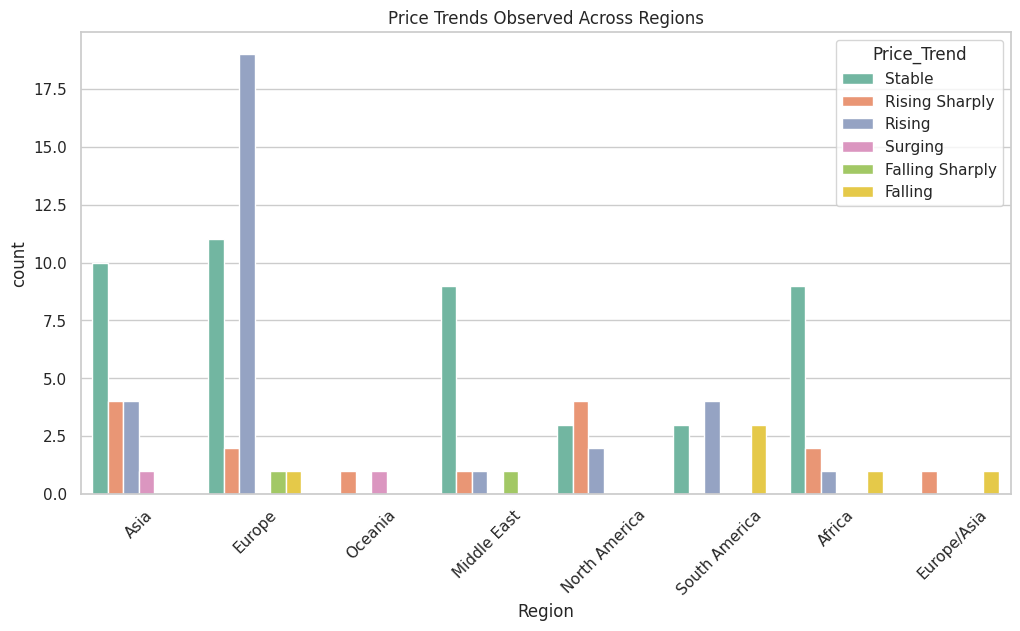

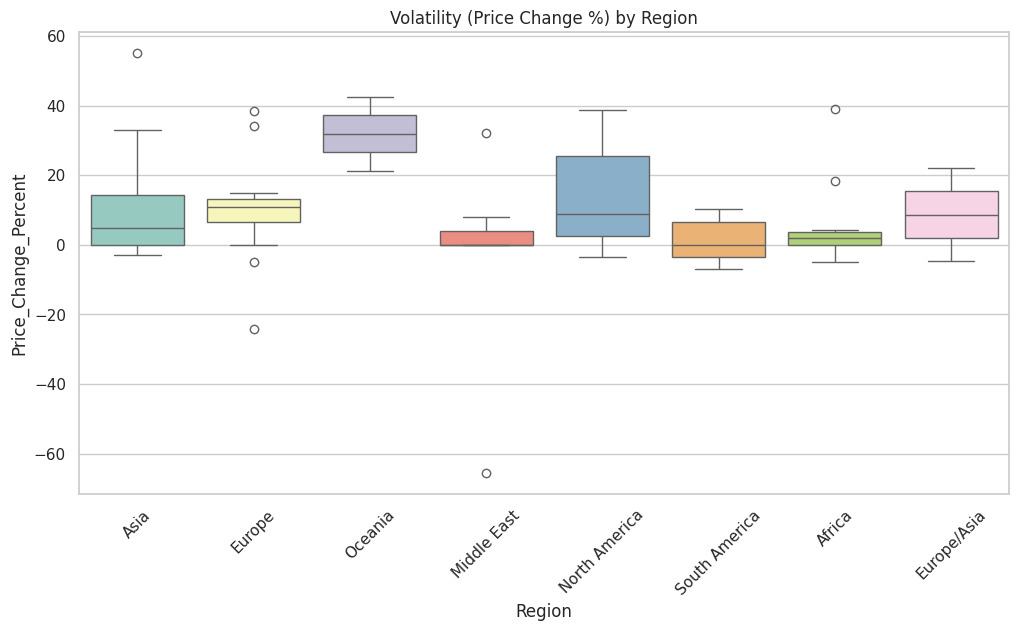

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_excel('/kaggle/input/datasets/fatimafarzand/global-petrol-prices-april-2026/Petrol prices.xlsx')

# Set style
sns.set_theme(style="whitegrid")

# 1. Global Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Price_Per_Liter_USD'], kde=True, color='teal', bins=20)
plt.title('Global Petrol Price Distribution (USD per Liter)')
plt.xlabel('Price per Liter (USD)')
plt.ylabel('Number of Countries')
plt.show()

# 2. Average Price by Region (Sorted)
plt.figure(figsize=(12, 6))
region_order = df.groupby('Region')['Price_Per_Liter_USD'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Region', y='Price_Per_Liter_USD', order=region_order, palette='coolwarm', errorbar=None)
plt.xticks(rotation=45)
plt.title('Average Petrol Price by Region')
plt.ylabel('Price per Liter (USD)')
plt.show()

# 3. Price Level Composition
plt.figure(figsize=(8, 8))
price_level_counts = df['Price_Level'].value_counts()
plt.pie(price_level_counts, labels=price_level_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Breakdown of Countries by Price Level')
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['float64']).corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix of Price Metrics')
plt.show()

# 5. Price Change vs. Price Level
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='Price_Level', y='Price_Change_Percent', hue='Region', jitter=True, alpha=0.6)
plt.title('Price Change Percentage across Price Levels')
plt.ylabel('Price Change (%)')
plt.show()

# 6. Current vs Previous Price (Top 15 Expensive)
top_15 = df.nlargest(15, 'Price_Per_Liter_USD')
plt.figure(figsize=(14, 7))
x = range(len(top_15))
plt.bar(x, top_15['Price_Per_Liter_USD'], width=0.4, label='Current Price', align='center', color='crimson')
plt.bar(x, top_15['Previous_Price_USD'], width=0.4, label='Previous Price', align='edge', color='gray', alpha=0.5)
plt.xticks(x, top_15['Country'], rotation=45)
plt.legend()
plt.title('Current vs. Previous Price for Top 15 Most Expensive Countries')
plt.ylabel('Price per Liter (USD)')
plt.show()

# 7. Distribution of Price Trends by Region
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Region', hue='Price_Trend', palette='Set2')
plt.xticks(rotation=45)
plt.title('Price Trends Observed Across Regions')
plt.show()

# 8. Boxplot of Price Change by Region
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Region', y='Price_Change_Percent', palette='Set3')
plt.xticks(rotation=45)
plt.title('Volatility (Price Change %) by Region')
plt.show()